# UAV Battery Tool — Notebook 04: Flight Log Analysis & Parameter Reverse-Engineering

Import real ArduPilot flight logs (.bin/.log/.csv), analyse battery performance, and reverse-engineer electrochemical parameters for improved simulation accuracy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

from batteries.database import BatteryDatabase
from batteries.log_importer import load_log, generate_synthetic_log
from batteries.parameter_fitter import (
    fit_all, apply_fitted_params,
    fit_internal_resistance, fit_ocv_curve, fit_peukert_k, fit_arrhenius,
)
from mission.simulator import run_simulation

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25})

DB_PATH = '../battery_db.xlsx'
db = BatteryDatabase(DB_PATH).load()
print(db.summary())

═══ Battery Database Summary ═══
  Chemistries       : 9
  Cells             : 11
  Battery packs     : 125
  Discharge points  : 132
  Equipment items   : 29
  UAV configurations: 3
  Mission profiles  : 3


## 1 · Load Flight Log

Change `LOG_PATH` to your actual ArduPilot log. Use `generate_synthetic_log()` for testing.

In [2]:
# ── Load settings from 00_configurator.ipynb (analysis_config.json) ───────────
import json as _json, os as _os
_CFG_PATH = _os.path.join(_os.path.dirname(_os.path.abspath('.')), 'analysis_config.json')
if not _os.path.exists(_CFG_PATH):
    _CFG_PATH = 'analysis_config.json'
_cfg = {}
if _os.path.exists(_CFG_PATH):
    with open(_CFG_PATH) as _f:
        _cfg = _json.load(_f)
    print(f'Loaded config from {_CFG_PATH}')
else:
    print('No analysis_config.json found — using defaults below (run 00_configurator first)')

# ── Values from configurator (overridden by manual entries below if desired) ───
PACK_ID        = (_cfg.get('selected_batteries', ['BAT_MID_6S2P'])[0]
                  if isinstance(_cfg.get('selected_batteries'), list)
                  else 'BAT_MID_6S2P')
MISSION_ID     = _cfg.get('mission_id',     'SURVEY_STD')
UAV_ID         = _cfg.get('uav_id',         'HEX_SURVEY_900')
AMBIENT_TEMP_C = _cfg.get('ambient_temp_c', 25.0)

# ── Manual overrides (uncomment to override configurator values) ────────────
# ── Configuration ─────────────────────────────────────────────────────────────
USE_SYNTHETIC    = True     # Set False when you have a real log file
LOG_PATH         = '../logs/your_flight.bin'  # .bin, .log, or .csv
# PACK_ID          = 'BAT_MID_6S2P'
# MISSION_ID       = 'SURVEY_STD'
# UAV_ID           = 'HEX_SURVEY_900'
# AMBIENT_TEMP_C   = 22.0     # actual temperature during flight
# ─────────────────────────────────────────────────────────────────────────────

pack    = db.packs[PACK_ID]
mission = db.missions[MISSION_ID]
uav     = db.uav_configs[UAV_ID]

if USE_SYNTHETIC:
    print('Using synthetic log (simulated ArduPilot data with noise)...')
    log = generate_synthetic_log(pack, mission, uav, db.discharge_pts,
                                  ambient_temp_c=AMBIENT_TEMP_C, dt_s=2.0,
                                  noise_v=0.035, noise_i=1.2)
else:
    print(f'Loading: {LOG_PATH}')
    log = load_log(LOG_PATH, nominal_capacity_ah=pack.pack_capacity_ah)

print(log.summary())

Loaded config from analysis_config.json
Using synthetic log (simulated ArduPilot data with noise)...
FlightLog: synthetic  [synthetic]
  Duration    : 1468 s  (24.5 min)
  Samples     : 735
  V range     : 45.03 – 50.33 V
  Peak I      : 17.4 A  avg: 6.6 A
  Total mAh   : 2667 mAh  (126.7 Wh)
  Max temp    : 25.9 °C
  Has temp    : True
  Has resting V: False


## 2 · Raw Signal Exploration

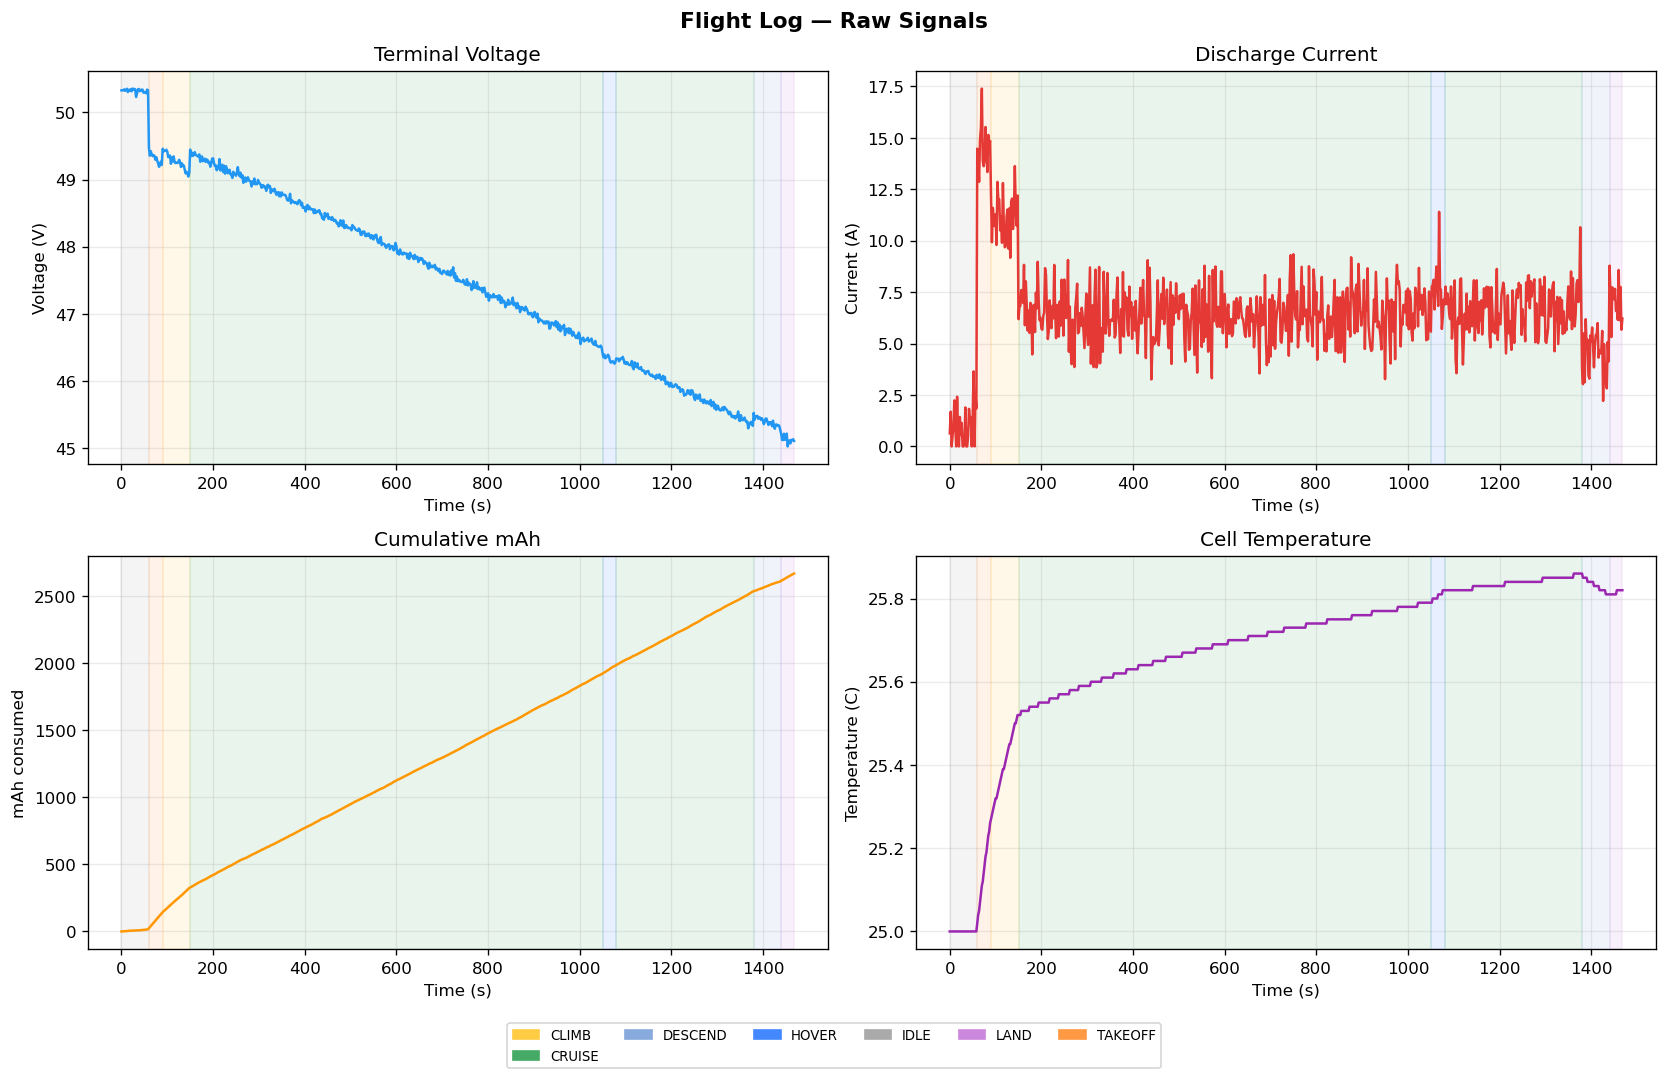

In [3]:
PHASE_COLORS = {
    'IDLE':            '#AAAAAA',
    'TAKEOFF':         '#FF9944',
    'CLIMB':           '#FFCC44',
    'CRUISE':          '#44AA66',
    'HOVER':           '#4488FF',
    'DESCEND':         '#88AADD',
    'LAND':            '#CC88DD',
    'PAYLOAD_OPS':     '#FF6688',
    'EMERGENCY':       '#FF2222',
    'VTOL_TRANSITION': '#FF6611',
    'VTOL_HOVER':      '#22AAFF',
    'FW_CRUISE':       '#00CC77',
    'FW_CLIMB':        '#AACC44',
    'FW_DESCEND':      '#99CCEE',
}
def shade(ax, log_obj):
    if not log_obj.phase_type: return
    prev, t0 = log_obj.phase_type[0], log_obj.time_s[0]
    for t, ph in zip(log_obj.time_s[1:], log_obj.phase_type[1:]):
        if ph != prev:
            ax.axvspan(t0, t, alpha=0.12, color=PHASE_COLORS.get(prev, '#CCC'))
            t0, prev = t, ph
    ax.axvspan(t0, log_obj.time_s[-1], alpha=0.12, color=PHASE_COLORS.get(prev, '#CCC'))

t   = np.array(log.time_s)
v   = np.array(log.voltage_v)
i   = np.array(log.current_a)
mah = np.array(log.mah_used)
tmp = np.array(log.temp_c)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Flight Log — Raw Signals', fontsize=13, fontweight='bold')

axes[0,0].plot(t, v, '#2196F3', linewidth=1.5)
shade(axes[0,0], log)
axes[0,0].set_ylabel('Voltage (V)'); axes[0,0].set_title('Terminal Voltage')

axes[0,1].plot(t, i, '#E53935', linewidth=1.5)
shade(axes[0,1], log)
axes[0,1].set_ylabel('Current (A)'); axes[0,1].set_title('Discharge Current')

axes[1,0].plot(t, mah, '#FF9800', linewidth=1.5)
shade(axes[1,0], log)
axes[1,0].set_ylabel('mAh consumed'); axes[1,0].set_title('Cumulative mAh')

if any(x > -50 for x in log.temp_c):
    axes[1,1].plot(t, tmp, '#9C27B0', linewidth=1.5)
    shade(axes[1,1], log)
    axes[1,1].set_ylabel('Temperature (C)'); axes[1,1].set_title('Cell Temperature')
else:
    axes[1,1].text(0.5, 0.5, 'No temperature data', transform=axes[1,1].transAxes, ha='center')

for ax in axes.flat: ax.set_xlabel('Time (s)')
patches = [mpatches.Patch(color=PHASE_COLORS.get(p, '#888'), label=p)
           for p in sorted(set(log.phase_type))]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=8)
plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig('log_raw_signals.png', bbox_inches='tight'); plt.show()

## 3 · V–I Relationship & IR Fingerprint

Visualise how voltage responds to current — the slope is the internal resistance.

Fitted R_internal: R_internal_mohm: 0.0000 ± 0.0000  R²=0.000  n=0


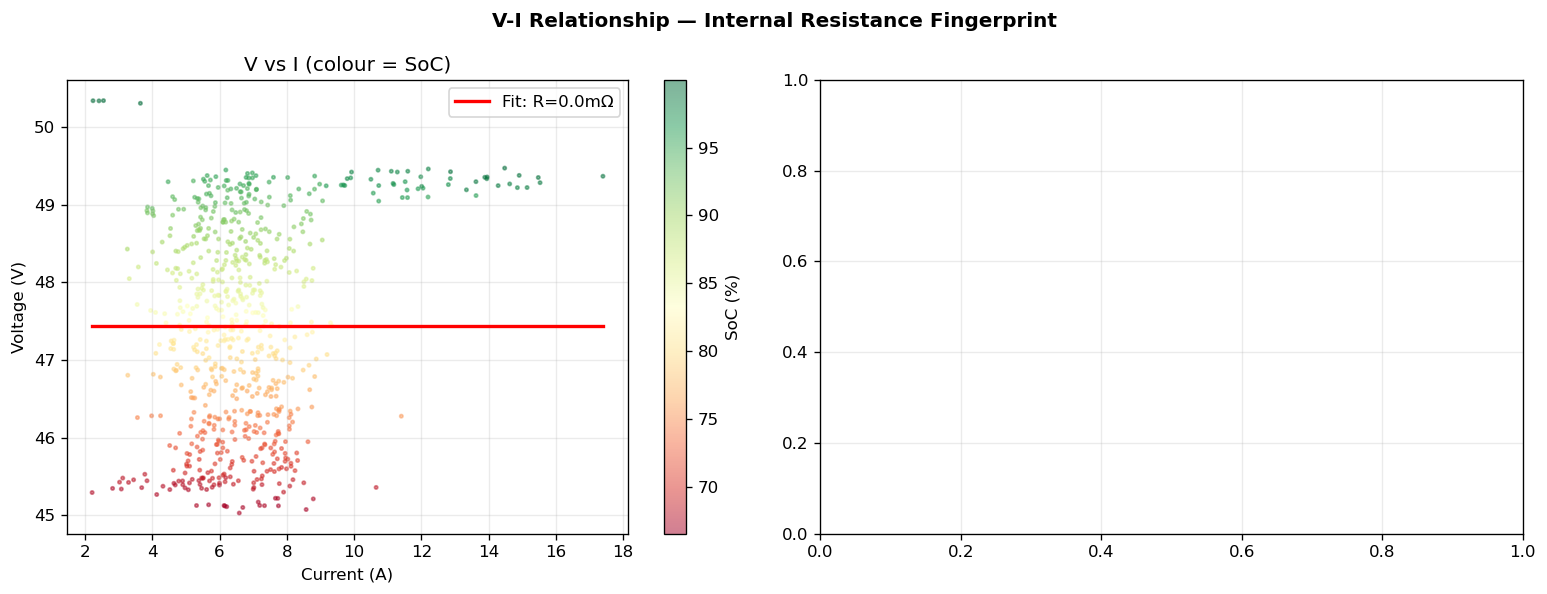

In [4]:
# Scatter V vs I, coloured by SoC
valid = (np.array(log.current_a) > 2) & (np.array(log.voltage_v) > 5)
i_v = np.array(log.current_a)[valid]
v_v = np.array(log.voltage_v)[valid]
soc_v = np.array(log.soc_pct)[valid] if log.soc_pct else np.linspace(100,0,valid.sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('V-I Relationship — Internal Resistance Fingerprint', fontsize=12, fontweight='bold')

sc = axes[0].scatter(i_v, v_v, c=soc_v, cmap='RdYlGn', s=4, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label='SoC (%)')
axes[0].set_xlabel('Current (A)'); axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('V vs I (colour = SoC)')

# IR fit per 5s window
from batteries.parameter_fitter import fit_internal_resistance
r_fit = fit_internal_resistance(log, method='window')
print(f'Fitted R_internal: {r_fit}')

# Overlay best-fit line at median SoC
i_range = np.linspace(i_v.min(), i_v.max(), 50)
v_ocv_est = float(np.median(v_v)) + float(np.median(i_v)) * r_fit.value / 1000
v_fit_line = v_ocv_est - i_range * r_fit.value / 1000
axes[0].plot(i_range, v_fit_line, 'r-', linewidth=2,
             label=f'Fit: R={r_fit.value:.1f}mΩ')
axes[0].legend()

# R² time-series across 5s windows
t_wins = np.arange(log.time_s[0], log.time_s[-1]-5, 2.5)
r_windows = []
t_arr = np.array(log.time_s)
for tw in t_wins:
    mask = valid & (t_arr >= tw) & (t_arr < tw+5)
    if mask.sum() < 6: r_windows.append(None); continue
    iv, vv = i_v[mask[valid]], v_v[mask[valid]]
    if iv.max()-iv.min() < 0.5: r_windows.append(None); continue
    coeffs = np.polyfit(iv, vv, 1)
    r_windows.append(-coeffs[0]*1000 if coeffs[0] < -0.0005 else None)

r_valid = [(t, r) for t, r in zip(t_wins, r_windows) if r and 0 < r < 400]
if r_valid:
    t_rv, r_rv = zip(*r_valid)
    axes[1].scatter(t_rv, r_rv, s=20, color='steelblue', alpha=0.7)
    axes[1].axhline(r_fit.value, color='red', linewidth=2, label=f'Median: {r_fit.value:.1f}mΩ')
    axes[1].axhline(pack.internal_resistance_mohm, color='green', linewidth=1.5,
                    linestyle='--', label=f'Catalog: {pack.internal_resistance_mohm}mΩ')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Fitted R (mΩ)')
    axes[1].set_title('Internal Resistance per 5-s Window')
    axes[1].legend()

plt.tight_layout(); plt.savefig('log_vi_analysis.png', bbox_inches='tight'); plt.show()

## 3b · Per-Phase Internal Resistance vs Discharge Rate

Fit internal resistance independently for each flight phase, then plot against discharge rate to reveal any current-dependence in the model.

 Phase  Mean I (A)  C-rate  R (mΩ)  CI lo (mΩ)  CI hi (mΩ)  R² fit  n samples  n inliers
CRUISE        6.44   0.805    85.1         3.6       168.7   0.006        600        600
 CLIMB       11.17   1.396     7.7       -28.7        56.2   0.004         30         30

Catalog R_internal: 36.0 mΩ


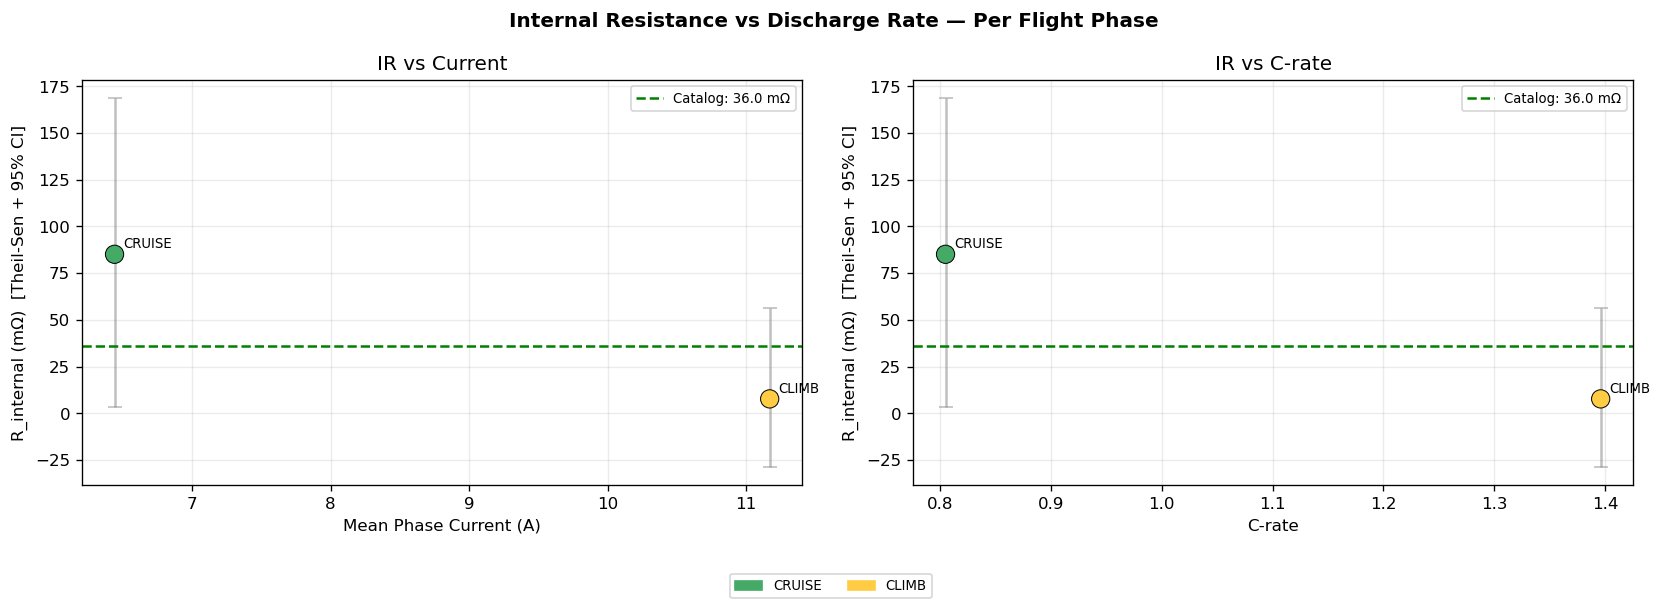

In [5]:
t_arr     = np.array(log.time_s)
v_arr     = np.array(log.voltage_v)
i_arr     = np.array(log.current_a)
phase_arr = np.array(log.phase_type) if log.phase_type else np.array(['UNKNOWN'] * len(t_arr))
phases    = sorted(set(phase_arr))

from scipy import stats

def robust_vi_fit(iv, vv):
    """Theil-Sen robust linear fit (V = Voc - R*I).
    Returns (r_mohm, r2, slope, intercept, lo_mohm, hi_mohm) where lo/hi are
    95% CI bounds on the resistance estimate.
    """
    res      = stats.theilslopes(vv, iv, 0.95)
    slope, intercept, lo, hi = res.slope, res.intercept, res.low_slope, res.high_slope
    r_mohm   = -slope * 1000
    lo_mohm  = -hi   * 1000  # high slope → low resistance
    hi_mohm  = -lo   * 1000
    residuals = vv - (slope * iv + intercept)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((vv - vv.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return r_mohm, r2, slope, intercept, lo_mohm, hi_mohm

# ── Fit R and collect stats per phase ─────────────────────────────────────────
rows = []
for phase in phases:
    mask = (phase_arr == phase) & (i_arr > 2) & (v_arr > 5)
    if mask.sum() < 6:
        continue
    iv, vv = i_arr[mask], v_arr[mask]
    if iv.max() - iv.min() < 0.5:
        continue

    # IQR outlier filter on residuals from a quick polyfit seed
    seed_c  = np.polyfit(iv, vv, 1)
    resid   = vv - np.polyval(seed_c, iv)
    q1, q3  = np.percentile(resid, [25, 75])
    iqr     = q3 - q1
    inliers = np.abs(resid - np.median(resid)) < 2.5 * iqr
    if inliers.sum() < 6:
        inliers = np.ones_like(inliers, dtype=bool)
    iv_in, vv_in = iv[inliers], vv[inliers]

    r_mohm, r2, slope, intercept, lo_mohm, hi_mohm = robust_vi_fit(iv_in, vv_in)
    if not (5 < r_mohm < 500):
        continue

    c_rate = iv_in.mean() / pack.pack_capacity_ah
    rows.append({
        'Phase':      phase,
        'Mean I (A)': round(iv_in.mean(), 2),
        'C-rate':     round(c_rate, 3),
        'R (mΩ)':     round(r_mohm, 1),
        'CI lo (mΩ)': round(lo_mohm, 1),
        'CI hi (mΩ)': round(hi_mohm, 1),
        'R² fit':     round(r2, 3),
        'n samples':  int(mask.sum()),
        'n inliers':  int(inliers.sum()),
        '_slope':     slope,
        '_intercept': intercept,
    })

df_phase = pd.DataFrame(rows).sort_values('Mean I (A)').reset_index(drop=True)
print(df_phase.drop(columns=['_slope', '_intercept']).to_string(index=False))
print(f'\nCatalog R_internal: {pack.internal_resistance_mohm} mΩ')

# ── Plot 1 & 2: IR per phase vs current and C-rate ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Internal Resistance vs Discharge Rate — Per Flight Phase',
             fontsize=12, fontweight='bold')

colors_ph = [PHASE_COLORS.get(p, '#888888') for p in df_phase['Phase']]
x  = df_phase['Mean I (A)'].values
y  = df_phase['R (mΩ)'].values
lo = df_phase['CI lo (mΩ)'].values
hi = df_phase['CI hi (mΩ)'].values

for ax_i, (xv, xlabel) in enumerate([(x, 'Mean Phase Current (A)'),
                                      (df_phase['C-rate'].values, 'C-rate')]):
    ax = axes[ax_i]
    yerr = np.array([y - lo, hi - y])
    ax.errorbar(xv, y, yerr=yerr, fmt='none', ecolor='gray', alpha=0.5, capsize=4)
    ax.scatter(xv, y, c=colors_ph, s=120, zorder=4, edgecolors='black', linewidths=0.6)
    for i_row, row in df_phase.iterrows():
        ax.annotate(row['Phase'], (xv[i_row], row['R (mΩ)']),
                    textcoords='offset points', xytext=(5, 4), fontsize=8)
    ax.axhline(pack.internal_resistance_mohm, color='green', linestyle='--',
               linewidth=1.5, label=f'Catalog: {pack.internal_resistance_mohm} mΩ')
    if len(x) >= 3:
        lin_c   = np.polyfit(xv, y, 1)
        xv_fit  = np.linspace(xv.min() * 0.9, xv.max() * 1.1, 100)
        ax.plot(xv_fit, np.polyval(lin_c, xv_fit), 'r-', linewidth=1.8,
                label=f'Trend: {lin_c[1]:.1f} + {lin_c[0]:.2f}·x mΩ')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('R_internal (mΩ)  [Theil-Sen + 95% CI]')
    ax.legend(fontsize=8)

axes[0].set_title('IR vs Current')
axes[1].set_title('IR vs C-rate')

patch_legend = [mpatches.Patch(color=PHASE_COLORS.get(p, '#888'), label=p)
                for p in df_phase['Phase']]
fig.legend(handles=patch_legend, loc='lower center', ncol=6, fontsize=8)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('ir_vs_discharge_rate.png', bbox_inches='tight')
plt.show()

if len(x) >= 3:
    lin_c = np.polyfit(x, y, 1)
    print(f'\nLinear model:  R(I) = {lin_c[1]:.2f} + {lin_c[0]:.4f} × I   (mΩ)')
    for ia in [0, 10, 20, 30]:
        print(f'  R at {ia:2d}A: {np.polyval(lin_c, ia):.1f} mΩ')


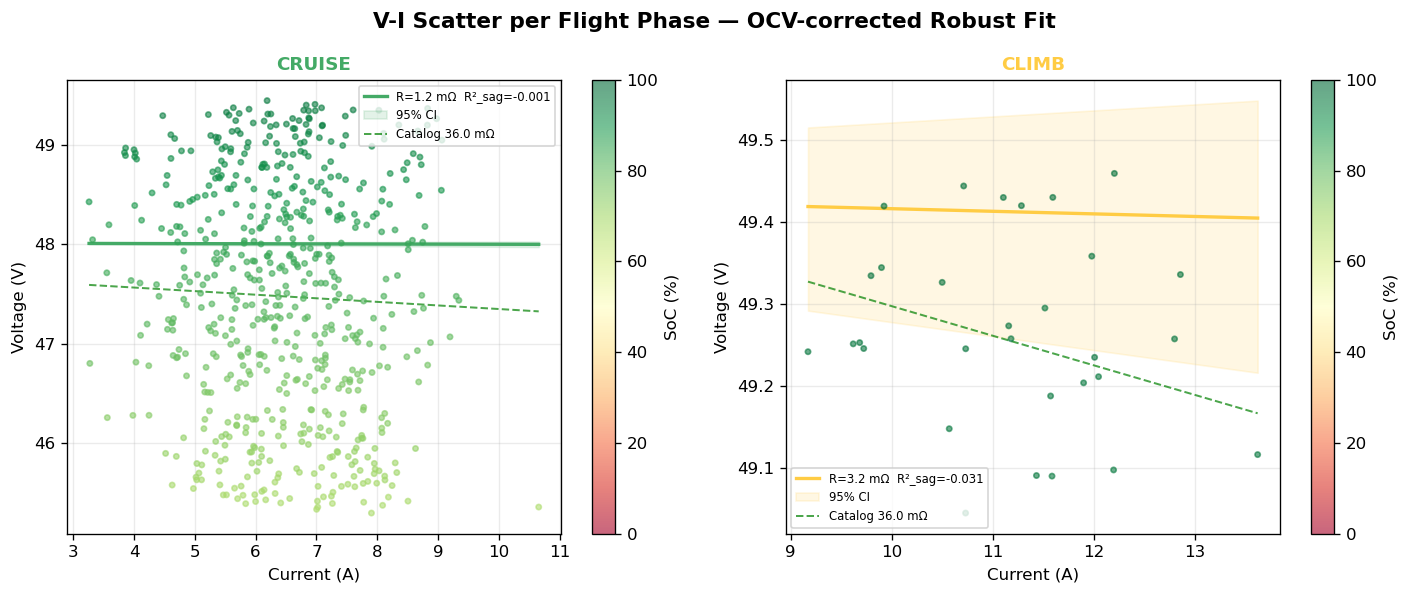

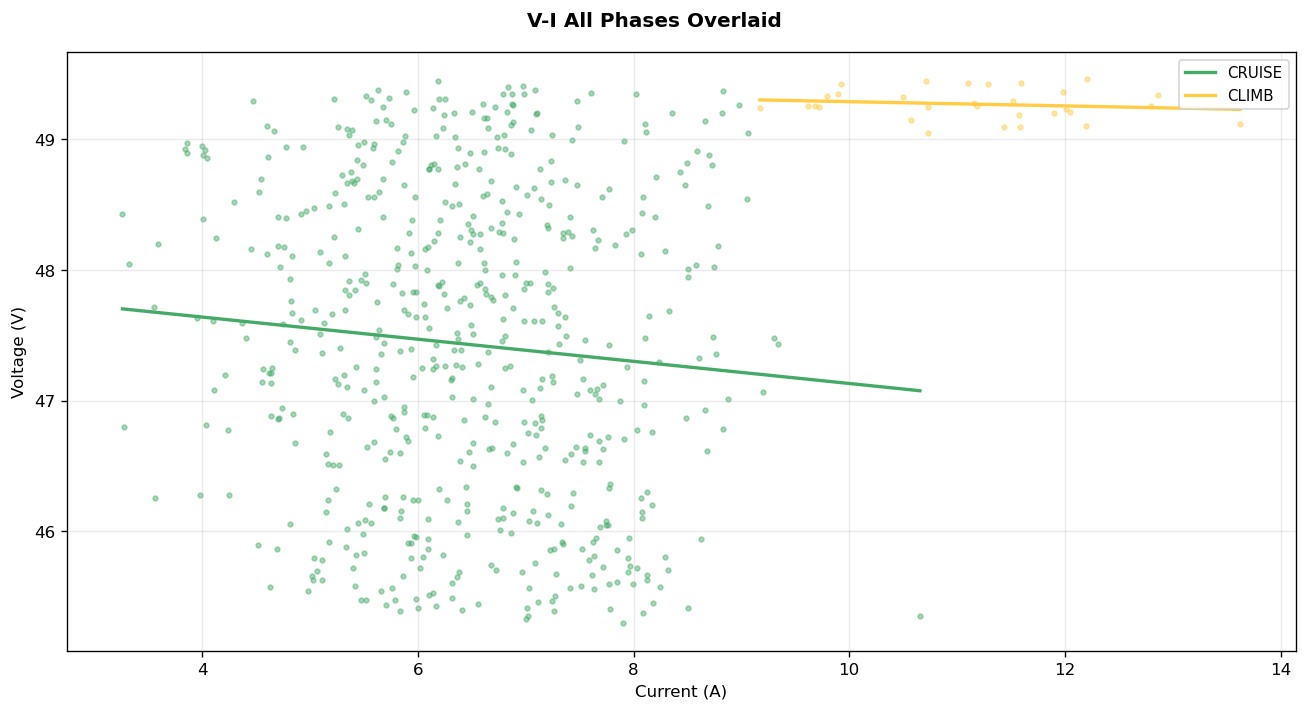

In [6]:
# ── Per-phase V-I scatter — OCV-corrected Theil-Sen robust fit ─────────────────
from scipy import stats

def soc_corrected_vi_fit(iv, vv, soc_v, deg=3):
    """Estimate R by removing OCV(SoC) polynomial trend, then Theil-Sen on sag.
    Returns (r_mohm, r_lo, r_hi, r2_sag, slope_v_per_a, v_ocv_mid) or None.
    """
    if len(iv) < 8 or iv.max() - iv.min() < 0.5:
        return None
    # Estimate OCV from a polynomial fit of (V + I*R_seed) vs SoC
    r_seed = -np.polyfit(iv, vv, 1)[0]  # quick seed
    v_ocv_est = vv + iv * r_seed
    coeffs_ocv = np.polyfit(soc_v, v_ocv_est, deg)
    v_ocv_fit  = np.polyval(coeffs_ocv, soc_v)
    v_sag      = v_ocv_fit - vv   # measured sag (V)
    # IQR filter on sag
    q1, q3 = np.percentile(v_sag, [25, 75])
    iqr     = q3 - q1
    ok      = np.abs(v_sag - np.median(v_sag)) < 2.5 * iqr
    if ok.sum() < 6:
        ok = np.ones_like(ok, dtype=bool)
    iv_ok, sag_ok = iv[ok], v_sag[ok]
    # Theil-Sen: V_sag = R * I  (force through origin not needed — use offset)
    res    = stats.theilslopes(sag_ok, iv_ok, 0.95)
    r_mohm = res.slope * 1000
    r_lo   = res.low_slope  * 1000
    r_hi   = res.high_slope * 1000
    # R² in sag domain
    v_sag_pred = iv_ok * res.slope + res.intercept
    ss_res = np.sum((sag_ok - v_sag_pred)**2)
    ss_tot = np.sum((sag_ok - sag_ok.mean())**2)
    r2_sag = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    v_ocv_mid = np.polyval(coeffs_ocv, np.median(soc_v))
    return r_mohm, r_lo, r_hi, r2_sag, res.slope, v_ocv_mid

n_phases = len(df_phase)
if n_phases > 0:
    soc_arr = np.array(log.soc_pct) if log.soc_pct else np.linspace(100, 0, len(t_arr))
    ncols = min(3, n_phases)
    nrows = int(np.ceil(n_phases / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    fig.suptitle('V-I Scatter per Flight Phase — OCV-corrected Robust Fit',
                 fontsize=13, fontweight='bold')

    for idx, row in df_phase.iterrows():
        ax    = axes[idx // ncols][idx % ncols]
        phase = row['Phase']
        mask  = (phase_arr == phase) & (i_arr > 2) & (v_arr > 5)
        iv, vv = i_arr[mask], v_arr[mask]
        soc_ph = soc_arr[mask]
        color  = PHASE_COLORS.get(phase, '#E53935')

        sc = ax.scatter(iv, vv, c=soc_ph, cmap='RdYlGn', s=10, alpha=0.6,
                        vmin=0, vmax=100, zorder=3)
        plt.colorbar(sc, ax=ax, label='SoC (%)')

        fit = soc_corrected_vi_fit(iv, vv, soc_ph)
        i_range = np.linspace(iv.min(), iv.max(), 80)
        if fit:
            r_mohm, r_lo, r_hi, r2_sag, slope, v_ocv_mid = fit
            v_line    = v_ocv_mid - i_range * slope
            v_lo_line = v_ocv_mid - i_range * (r_hi / 1000)
            v_hi_line = v_ocv_mid - i_range * (r_lo / 1000)
            ax.plot(i_range, v_line, color=color, linewidth=2,
                    label=f'R={r_mohm:.1f} mΩ  R²_sag={r2_sag:.3f}')
            ax.fill_between(i_range, v_lo_line, v_hi_line,
                            color=color, alpha=0.15, label='95% CI')
        else:
            coeffs = np.polyfit(iv, vv, 1)
            ax.plot(i_range, np.polyval(coeffs, i_range), color=color, linewidth=2,
                    label=f'R={row["R (mΩ)"]:.1f} mΩ (polyfit)')

        # Catalog reference
        i_med   = iv.mean()
        v_ocv_e = np.median(vv) + i_med * pack.internal_resistance_mohm / 1000
        v_cat   = v_ocv_e - i_range * pack.internal_resistance_mohm / 1000
        ax.plot(i_range, v_cat, 'g--', linewidth=1.2,
                label=f'Catalog {pack.internal_resistance_mohm} mΩ', alpha=0.7)

        ax.set_title(phase, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Current (A)')
        ax.set_ylabel('Voltage (V)')
        ax.legend(fontsize=7)

    for idx in range(n_phases, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    plt.savefig('ir_phase_vi_scatter.png', bbox_inches='tight')
    plt.show()

    # ── Overlay plot ──────────────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(11, 6))
    fig2.suptitle('V-I All Phases Overlaid', fontsize=12, fontweight='bold')
    for _, row in df_phase.iterrows():
        phase  = row['Phase']
        mask   = (phase_arr == phase) & (i_arr > 2) & (v_arr > 5)
        iv, vv = i_arr[mask], v_arr[mask]
        color  = PHASE_COLORS.get(phase, '#888888')
        ax2.scatter(iv, vv, color=color, s=8, alpha=0.45)
        i_range = np.linspace(iv.min(), iv.max(), 60)
        ax2.plot(i_range, np.polyval(np.polyfit(iv, vv, 1), i_range),
                 color=color, linewidth=2, label=phase)
    ax2.set_xlabel('Current (A)')
    ax2.set_ylabel('Voltage (V)')
    ax2.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.savefig('ir_phase_vi_overlay.png', bbox_inches='tight')
    plt.show()
else:
    print('No phases with sufficient data to plot.')


## 4 · Full Parameter Fitting Pipeline

In [7]:
print('Running full parameter fitting pipeline...')
fitted = fit_all(
    log=log,
    nominal_capacity_ah=pack.pack_capacity_ah,
    voltage_cutoff_v_pack=pack.pack_voltage_cutoff,
    chem_id=pack.chemistry_id,
    pack_id=pack.battery_id,
)
print()
print(fitted.summary())

Running full parameter fitting pipeline...
  [1/5] Fitting internal resistance...
        R_internal_mohm: 9.9510 ± 17.7060  R²=0.208  n=709
  [2/5] Reconstructing OCV curve...
        2 OCV points  R²=0.000
  [3/5] Fitting Peukert exponent...
        peukert_k: 1.0372 ± 0.0085  R²=0.000  n=724
  [4/5] Fitting Arrhenius temperature coefficients...
        B_ohmic_K: 0.0000 ± 0.0000  R²=0.000  n=0
        B_ct_K: 0.0000 ± 0.0000  R²=0.000  n=0
  [5/5] Estimating actual capacity...
        actual_capacity_ah: 8.0000 ± 0.0000  R²=0.000  n=0

══ Fitted Battery Parameters ══
  R_internal   : R_internal_mohm: 9.9510 ± 17.7060  R²=0.208  n=709
  Capacity     : actual_capacity_ah: 8.0000 ± 0.0000  R²=0.000  n=0
  Peukert k    : peukert_k: 1.0372 ± 0.0085  R²=0.000  n=724
  B_ohmic      : B_ohmic_K: 0.0000 ± 0.0000  R²=0.000  n=0
  B_ct         : B_ct_K: 0.0000 ± 0.0000  R²=0.000  n=0
  OCV curve    : 2 points fitted
  ⚠  IR regression R²=0.21 — low confidence (<0.5). Consider filtering out tra

## 5 · OCV Curve Comparison

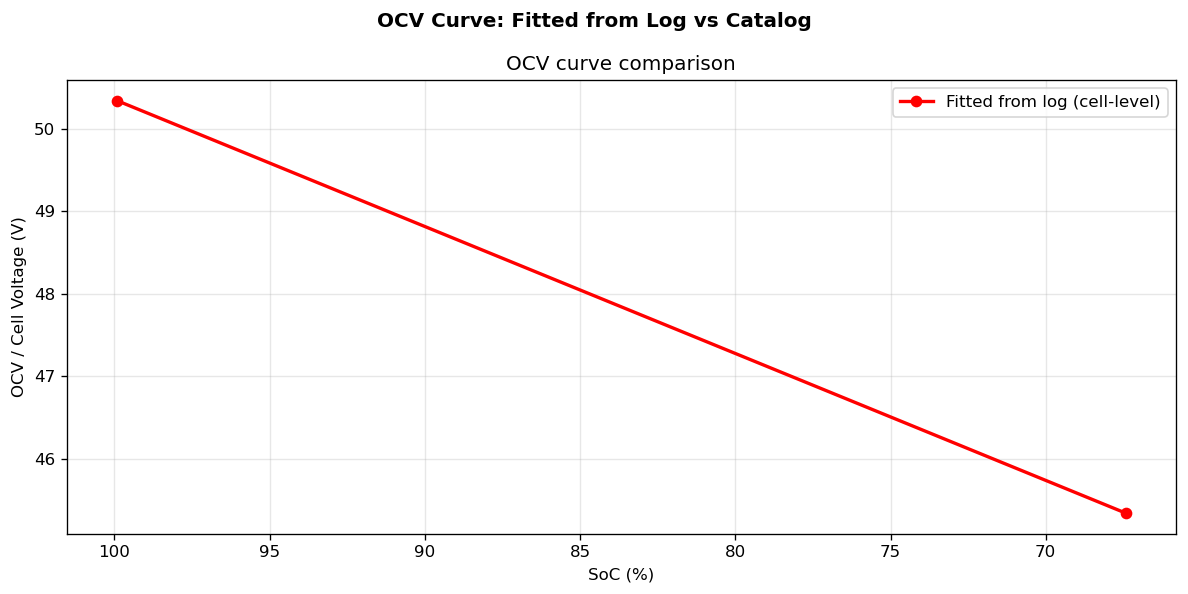

In [8]:
from batteries.discharge import DischargeCurve, available_c_rates, closest_c_rate

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('OCV Curve: Fitted from Log vs Catalog', fontsize=12, fontweight='bold')

if fitted.ocv_soc_points:
    ax.plot(fitted.ocv_soc_points, fitted.ocv_voltage_points, 'ro-',
            linewidth=2, markersize=6, label='Fitted from log (cell-level)')

avail = available_c_rates(db.discharge_pts, pack.chemistry_id)
if avail:
    cr = closest_c_rate(avail, 0.5)
    curve = DischargeCurve(db.discharge_pts, pack.chemistry_id, cr, 25.0)
    soc_c = curve.soc_array()
    v_c   = curve.voltage_array()
    ax.plot(soc_c, v_c, 'b-', linewidth=2, alpha=0.7, label=f'Catalog ({cr}C)')

ax.set_xlabel('SoC (%)'); ax.set_ylabel('OCV / Cell Voltage (V)')
ax.set_title('OCV curve comparison'); ax.legend(); ax.grid(alpha=0.3)
ax.invert_xaxis()
plt.tight_layout(); plt.savefig('ocv_comparison.png', bbox_inches='tight'); plt.show()

## 6 · Simulation Comparison: Catalog vs Fitted Parameters

Catalog params simulation:
════════════════════════════════════════════════════
 Simulation: BAT_LE_12S2P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1469 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 66.6 %
  Min voltage      : 45.078 V
  Max current      : 14.7 A
  Peak sag total   : 0.945 V
  Peak temperature : 25.8 °C

Fitted params simulation:
════════════════════════════════════════════════════
 Simulation: BAT_LE_12S2P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1469 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 66.8 %
  Min voltage      : 45.434 V
  Max current      : 14.5 A
  Peak sag total   : 0.258 V
  Peak temperature : 25.2 °C


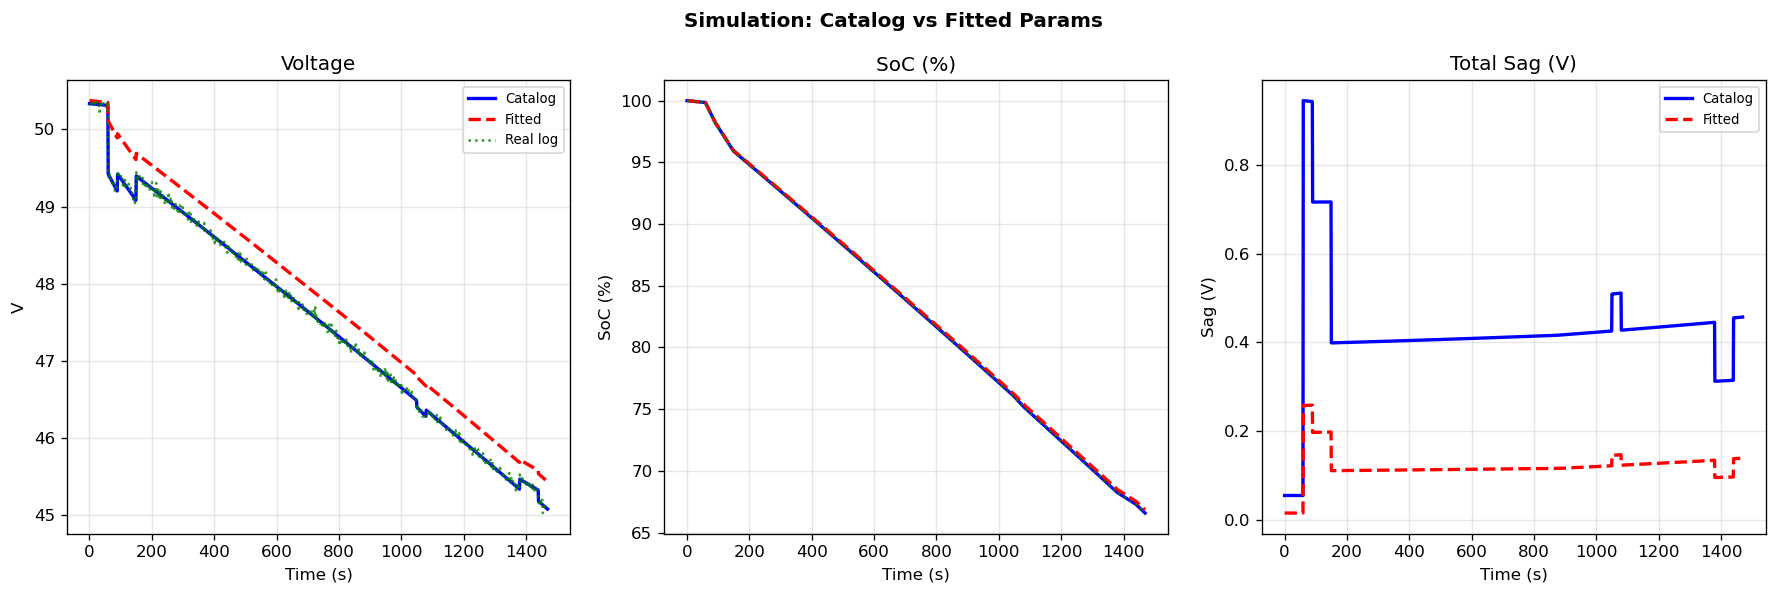

In [9]:
pack_fitted = apply_fitted_params(fitted, pack)

r_catalog = run_simulation(pack, mission, uav, db.discharge_pts,
                           ambient_temp_c=AMBIENT_TEMP_C, dt_s=1.0)
r_fitted  = run_simulation(pack_fitted, mission, uav, db.discharge_pts,
                           ambient_temp_c=AMBIENT_TEMP_C, dt_s=1.0)

print('Catalog params simulation:')
print(r_catalog.summary())
print()
print('Fitted params simulation:')
print(r_fitted.summary())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Simulation: Catalog vs Fitted Params', fontsize=12, fontweight='bold')

axes[0].plot(np.array(r_catalog.time_s), np.array(r_catalog.voltage_v),
             'b-', linewidth=2, label='Catalog')
axes[0].plot(np.array(r_fitted.time_s),  np.array(r_fitted.voltage_v),
             'r--', linewidth=2, label='Fitted')
axes[0].plot(np.array(log.time_s), np.array(log.voltage_v),
             'g:', linewidth=1.5, alpha=0.8, label='Real log')
axes[0].set_title('Voltage'); axes[0].set_ylabel('V'); axes[0].legend(fontsize=8)

axes[1].plot(np.array(r_catalog.time_s), np.array(r_catalog.soc_pct), 'b-', linewidth=2)
axes[1].plot(np.array(r_fitted.time_s),  np.array(r_fitted.soc_pct),  'r--', linewidth=2)
if log.soc_pct:
    axes[1].plot(np.array(log.time_s), np.array(log.soc_pct), 'g:', linewidth=1.5, alpha=0.8)
axes[1].set_title('SoC (%)'); axes[1].set_ylabel('SoC (%)')

dv_cat = np.array(r_catalog.dv_ohmic)+np.array(r_catalog.dv_ct)+np.array(r_catalog.dv_conc)
dv_fit = np.array(r_fitted.dv_ohmic)+np.array(r_fitted.dv_ct)+np.array(r_fitted.dv_conc)
axes[2].plot(np.array(r_catalog.time_s), dv_cat, 'b-', linewidth=2, label='Catalog')
axes[2].plot(np.array(r_fitted.time_s),  dv_fit, 'r--', linewidth=2, label='Fitted')
axes[2].set_title('Total Sag (V)'); axes[2].set_ylabel('Sag (V)'); axes[2].legend(fontsize=8)

for ax in axes: ax.set_xlabel('Time (s)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('catalog_vs_fitted.png', bbox_inches='tight'); plt.show()

## 7 · Export Fitted Parameters to Database

Save the fitted pack to the Battery Catalog so it can be used in future simulations.

In [10]:
SAVE_FITTED_PACK = False   # Set True to write to battery_db.xlsx

pack_fitted.battery_id = f'{pack.battery_id}_FITTED'
pack_fitted.notes = (f'Fitted from log: IR={fitted.r_internal_mohm.value:.1f}mΩ  '
                     f'k={fitted.peukert_k.value:.4f}  '
                     f'degrade={fitted.degradation_pct:.1f}%')

print('Fitted pack summary:')
print(f'  Battery ID  : {pack_fitted.battery_id}')
print(f'  IR (mΩ)     : {pack_fitted.internal_resistance_mohm:.2f}  (catalog: {pack.internal_resistance_mohm})')
print(f'  Capacity    : {pack_fitted.pack_capacity_ah:.3f} Ah  (catalog: {pack.pack_capacity_ah})')
print(f'  Energy      : {pack_fitted.pack_energy_wh:.1f} Wh')

if SAVE_FITTED_PACK:
    db.append_custom_pack(pack_fitted)
    print(f'Saved to {DB_PATH}')
else:
    print('Set SAVE_FITTED_PACK = True to persist to battery_db.xlsx')

Fitted pack summary:
  Battery ID  : BAT_LE_12S2P_FITTED
  IR (mΩ)     : 9.95  (catalog: 36.0)
  Capacity    : 8.000 Ah  (catalog: 8.0)
  Energy      : 350.0 Wh
Set SAVE_FITTED_PACK = True to persist to battery_db.xlsx
